# Checkpoint 2: Research Question (RQ) Formation

# 1. Project Scope
* **Dataset:** Amazon Sales Dataset (50,000 transactions).
* **EDA Recap:** Initial exploration shows a highly balanced distribution of sales across four regions (Asia, North America, Europe, Middle East) and six discount levels (0-30%). Quantity sold per transaction is uniformly distributed between 1 and 5 units. Ratings average 3.0, suggesting a neutral-to-positive sentiment across categories.
* **Course Techniques:** Frequent Itemset Mining, Association Rule Mining (Apriori).
* **External Techniques:** One-Way ANOVA and Tukey’s HSD (Honestly Significant Difference) for statistical inference.





# 2. Research Question Definition
### **RQ1: Category-Specific Success Drivers**
* **Question:** Within each **product category**, are higher **discount tiers** and higher **rating tiers** associated with higher **quantity sold**?
* **Data Mining Task:** Association Rule Mining.
* **Algorithm(s):** Apriori-based (Course).
* **Evaluation Criteria:** Support (frequency of occurrence), Confidence (reliability of the rule), and Lift (strength of association over random chance).

### **RQ2: The Impact of Social Proof on Bulk Buying**
* **Question:** Across **product categories**, are higher **review counts** associated with higher **sales (quantity sold)**, and do **payment methods** vary by **product category**?
* **Data Mining Task:** Descriptive and Statistical Data Mining, Frequent Itemset Mining (Course).
* **Algorithm(s):** Apriori Logic (Course), Cross-tabulation (contingency tables), Chi-square test.
* **Evaluation Criteria:**
  - Conditional distributions (e.g., probability of high quantity sold given high review count)
  - Statistical significance (p-value from chi-square test)
  - Support of frequent itemsets for identifying common behavioral patterns

### **RQ3: Regional Discount Sensitivity & Elasticity**
* **Question:** Is there a statistically significant difference in how customers in different **Regions** respond to **Discount Tiers** in terms of **Quantity Sold**?
* **Data Mining Task:** Statistical Inference / Group Comparison.
* **Algorithm(s):** One-Way ANOVA and Tukey’s HSD (External).
* **Evaluation Criteria:** F-statistic, p-value (threshold < 0.05), and Mean Difference between specific regional pairs.



# Additional EDA:

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import kagglehub
import os

# 1. Load the dataset
try:
    path = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")
    csv_path = os.path.join(path, "amazon_sales_dataset.csv")
    df = pd.read_csv(csv_path)
    print("Dataset loaded successfully.\n")
except FileNotFoundError:
    print("Error: 'amazon_sales_dataset.csv' not found.")


# Quick check for data issues before mining
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
# Basic noise check: ensure no negative quantities or impossible ratings
print(f"Invalid Ratings Check: {df[df['rating'] > 5].shape[0]} rows")

# --- DATA PREPARATION (Discretization) ---
# We must bin continuous data for Association/Frequent Itemset mining.
df['disc_bin'] = pd.cut(df['discount_percent'], bins=[-1, 5, 20, 31], labels=['Low_Disc', 'Mid_Disc', 'High_Disc'])
df['rate_bin'] = pd.cut(df['rating'], bins=[0, 2, 4, 5.1], labels=['Poor_Rate', 'Avg_Rate', 'High_Rate'])
df['qty_bin'] = pd.cut(df['quantity_sold'], bins=[0, 1, 3, 6], labels=['Single_Qty', 'Multi_Qty', 'Bulk_Qty'])
df['review_bin'] = pd.cut(df['review_count'], bins=[-1, 100, 300, 501], labels=['Niche', 'Steady', 'Popular'])


# =================================================================
# RESEARCH QUESTION 1: Association Rules Within Each Product Category (Course Method)
# =================================================================

print("--- RQ1: Dominant Association Rules Within Each Product Category ---")
print("Goal: Identify dominant rules between Discount Tiers, Rating Tiers, and Quantity Sold.\n")

categories = df['product_category'].dropna().unique()
rq1_results = []

for category in categories:
    print(f"\n==============================")
    print(f"Category: {category}")
    print(f"==============================")

    # Select one product category at a time
    subset_rq1 = df[df['product_category'] == category][['disc_bin', 'rate_bin', 'qty_bin']]

    # One-hot encode categorical bins for Apriori
    encoded_rq1 = pd.get_dummies(subset_rq1)

    # Generate frequent itemsets
    freq_itemsets_rq1_cat = apriori(
        encoded_rq1,
        min_support=0.05,
        use_colnames=True
    )

    if freq_itemsets_rq1_cat.empty:
        print("No frequent itemsets found for this category.")
        continue

    # Generate association rules
    rules_rq1_cat = association_rules(
        freq_itemsets_rq1_cat,
        metric="lift",
        min_threshold=1.0
    )

    if rules_rq1_cat.empty:
        print("No association rules found for this category.")
        continue

    # Add category label
    rules_rq1_cat['product_category'] = category

    # Sort by strongest association first
    rules_rq1_cat = rules_rq1_cat.sort_values(
        by=['lift', 'confidence', 'support'],
        ascending=[False, False, False]
    )

    # Store all category-specific rules
    rq1_results.append(rules_rq1_cat)

    # Print top 10 dominant rules for this category
    print(
        rules_rq1_cat[
            ['antecedents', 'consequents', 'support', 'confidence', 'lift']
        ].head(10)
    )

# =================================================================
# Combine all category-specific RQ1 rules
# =================================================================

rq1_columns = [
    'product_category', 'antecedents', 'consequents',
    'support', 'confidence', 'lift'
]

if rq1_results:
    rules_rq1 = pd.concat(rq1_results, ignore_index=True)
else:
    rules_rq1 = pd.DataFrame(columns=rq1_columns)

print("\n--- Combined RQ1 Results ---")

if not rules_rq1.empty:
    print(rules_rq1[rq1_columns].head(20))
else:
    print("No association rules were found across categories.")

# =================================================================
# Top 5 Dominant Rules Per Category
# =================================================================

print("\n--- Top 5 Dominant Rules Per Category ---")

if not rules_rq1.empty:
    top_rules_per_category = (
        rules_rq1
        .sort_values(
            by=['product_category', 'lift', 'confidence', 'support'],
            ascending=[True, False, False, False]
        )
        .groupby('product_category')
        .head(5)
        .reset_index(drop=True)
    )

    print(top_rules_per_category[rq1_columns])
else:
    top_rules_per_category = pd.DataFrame(columns=rq1_columns)
    print("No top category rules available.")

# =================================================================
# Focused View: Rules Where Quantity Sold Is the Consequent
# =================================================================

print("\n--- Focused View: Rules Predicting Quantity Sold ---")

if not rules_rq1.empty:
    quantity_rules_rq1 = rules_rq1[
        rules_rq1['consequents'].apply(
            lambda x: any('qty_bin' in item for item in x)
        )
    ]

    quantity_rules_rq1 = quantity_rules_rq1.sort_values(
        by=['lift', 'confidence', 'support'],
        ascending=[False, False, False]
    )

    if not quantity_rules_rq1.empty:
        print(
            quantity_rules_rq1[
                ['product_category', 'antecedents', 'consequents',
                 'support', 'confidence', 'lift']
            ].head(20)
        )
    else:
        print("No rules found where Quantity Sold is the consequent.")
else:
    quantity_rules_rq1 = pd.DataFrame(columns=rq1_columns)
    print("No RQ1 rules available for quantity-focused analysis.")


# =================================================================
# RESEARCH QUESTION 2: Review Count, Sales, and Payment Behavior
# =================================================================

print("--- RQ2: Review Count, Sales, and Payment Behavior ---")

# ================================================================
# PART 1: Review Count vs Quantity Sold Across Product Categories
# ================================================================

print("\n=== Part 1: Review Count vs Quantity Sold Across Categories ===")

categories = df['product_category'].dropna().unique()
rq2_review_sales_results = []

for category in categories:
    print(f"\nCategory: {category}")

    df_cat = df[df['product_category'] == category]

    review_qty_table = pd.crosstab(
        df_cat['review_bin'],
        df_cat['qty_bin'],
        normalize='index'
    )

    print(review_qty_table)

    # Probability of higher sales given high review count
    prob_bulk_given_popular = review_qty_table.loc['Popular', 'Bulk_Qty'] if (
        'Popular' in review_qty_table.index and 'Bulk_Qty' in review_qty_table.columns
    ) else np.nan

    rq2_review_sales_results.append({
        'product_category': category,
        'P(Bulk_Qty | Popular Reviews)': prob_bulk_given_popular
    })

rq2_review_sales_summary = pd.DataFrame(rq2_review_sales_results)

print("\n--- Summary: Probability of Bulk Quantity Given Popular Reviews ---")
print(rq2_review_sales_summary.sort_values(
    by='P(Bulk_Qty | Popular Reviews)',
    ascending=False
))


# ================================================================
# PART 2: Payment Method vs Product Category
# ================================================================

print("\n=== Part 2: Payment Method Distribution by Product Category ===")

payment_category_table = pd.crosstab(
    df['product_category'],
    df['payment_method'],
    normalize='index'
)

print(payment_category_table)


# Chi-square test of independence
payment_category_raw = pd.crosstab(
    df['product_category'],
    df['payment_method']
)

chi2, p_value, dof, expected = chi2_contingency(payment_category_raw)

print("\n--- Chi-square Test: Product Category vs Payment Method ---")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")


# ================================================================
# PART 3: Frequent Itemset Mining as Supporting Exploration
# ================================================================

print("\n=== Part 3: Frequent Itemset Mining for Review, Quantity, Payment, and Category ===")

subset_rq2 = df[['product_category', 'review_bin', 'qty_bin', 'payment_method']]
encoded_rq2 = pd.get_dummies(subset_rq2)

freq_itemsets_rq2 = apriori(
    encoded_rq2,
    min_support=0.02,
    use_colnames=True
)

# Focus on itemsets that include review count and quantity sold
review_qty_itemsets = freq_itemsets_rq2[
    freq_itemsets_rq2['itemsets'].apply(
        lambda x: any('review_bin' in item for item in x) and
                  any('qty_bin' in item for item in x)
    )
].sort_values(by='support', ascending=False)

print("\n--- Frequent Itemsets Containing Review Count and Quantity Sold ---")
print(review_qty_itemsets.head(15))


# Focus on itemsets that include product category and payment method
category_payment_itemsets = freq_itemsets_rq2[
    freq_itemsets_rq2['itemsets'].apply(
        lambda x: any('product_category' in item for item in x) and
                  any('payment_method' in item for item in x)
    )
].sort_values(by='support', ascending=False)

print("\n--- Frequent Itemsets Containing Product Category and Payment Method ---")
print(category_payment_itemsets.head(15))

# =================================================================
# RESEARCH QUESTION 3: ANOVA & Tukey HSD (External Method)
# =================================================================
print("\n--- RQ3: Regional Discount Sensitivity (ANOVA & Tukey) ---")

# Step A: Filter for "High Discount" transactions to test sensitivity
high_disc_df = df[df['disc_bin'] == 'High_Disc']

# Step B: One-Way ANOVA
regions = high_disc_df['customer_region'].unique()
args = [high_disc_df[high_disc_df['customer_region'] == r]['quantity_sold'] for r in regions]
f_stat, p_val = stats.f_oneway(*args)

print(f"ANOVA Results: F={f_stat:.4f}, p={p_val:.4f}")

# Step C: Tukey HSD (Built-in Post-hoc test)
if p_val < 0.05:
    print("Significant difference found. Running Tukey HSD...")
    tukey = pairwise_tukeyhsd(endog=high_disc_df['quantity_sold'],
                              groups=high_disc_df['customer_region'],
                              alpha=0.05)
    print(tukey)
else:
    print("No significant regional difference in discount sensitivity.")


# =================================================================
# VALIDATION TESTS (Addressing Rubric: Non-trivial Behavior)
# =================================================================

print("\n--- Validation & Quality Tests ---")

# 1. Validate Association Rule Significance (RQ1)
# Non-trivial behavior check: Are there any rules with Lift > 1.02?
# If Lift is 1.0, the variables are independent (trivial).
high_lift_rules = rules_rq1[rules_rq1['lift'] > 1.02]
print(f"Test 1 (Strength of Association): {len(high_lift_rules)} non-trivial rules found with Lift > 1.02.")

# 2. Validate Frequent Itemset Complexity (RQ2)
# Non-trivial behavior check: Are we finding itemsets with more than 1 item?
multi_itemsets = freq_itemsets_rq2[freq_itemsets_rq2['itemsets'].apply(len) > 1]
print(f"Test 2 (Pattern Complexity): {len(multi_itemsets)} multi-variable itemsets discovered.")

# 3. Validate ANOVA Assumptions (RQ3)
# Non-trivial behavior check: Is the variance stable enough for ANOVA?
# We use Levene's Test to validate the 'Homogeneity of Variance' assumption.
levene_p = stats.levene(*args).pvalue
print(f"Test 3 (Statistical Assumption): Levene’s p-value = {levene_p:.4f}")

if levene_p > 0.05:
    print("   > Result: Variance is homogeneous. ANOVA results are mathematically valid.")
else:
    print("   > Result: Variance is heterogeneous. ANOVA results should be interpreted with caution.")

# 4. Consistency Check
# Ensure the number of transactions processed matches the expected dataset size
print(f"Test 4 (Data Integrity): Processed {len(df)} records successfully.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
  0%|          | 0.00/1.24M [00:00<?,

Extracting files...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packa

Dataset loaded successfully.

Missing values:
order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64
Duplicate rows: 0
Invalid Ratings Check: 0 rows
--- RQ1: Dominant Association Rules Within Each Product Category ---
Goal: Identify dominant rules between Discount Tiers, Rating Tiers, and Quantity Sold.


Category: Books
                                antecedents  \
38   (rate_bin_High_Rate, qty_bin_Bulk_Qty)   
43                      (disc_bin_Mid_Disc)   
42                       (qty_bin_Bulk_Qty)   
39  (rate_bin_High_Rate, disc_bin_Mid_Disc)   
40    (qty_bin_Bulk_Qty, disc_bin_Mid_Disc)   
41                     (rate_bin_High_Rate)   
12                     (qty_bin_Single_Qty)   
13                     (rate_bin_Poor_Rate)   
25  (rate_

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

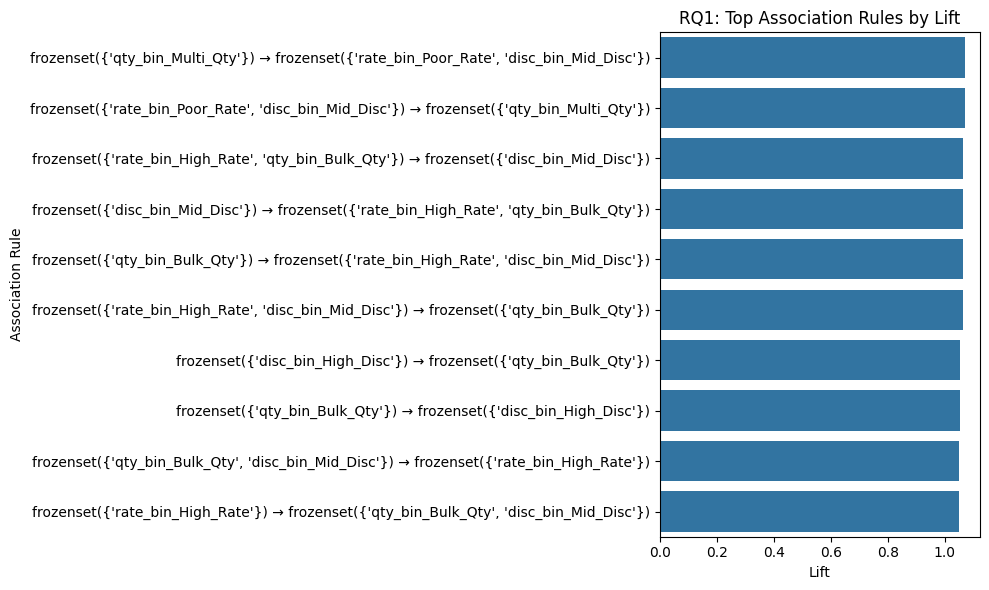

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

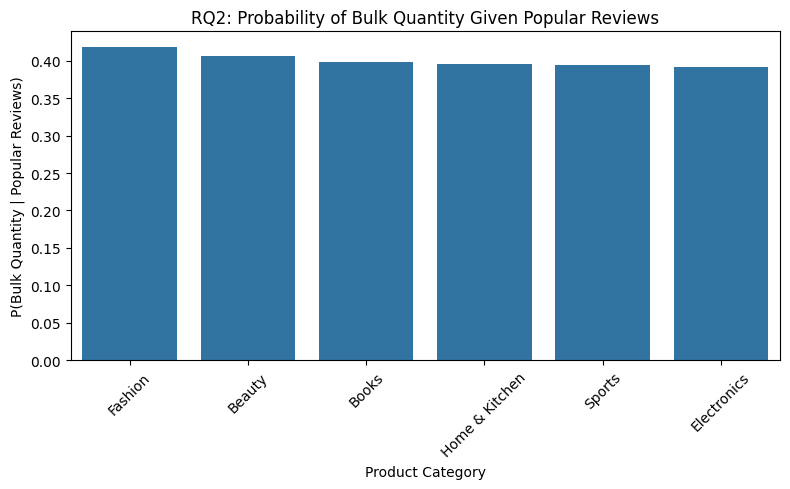

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

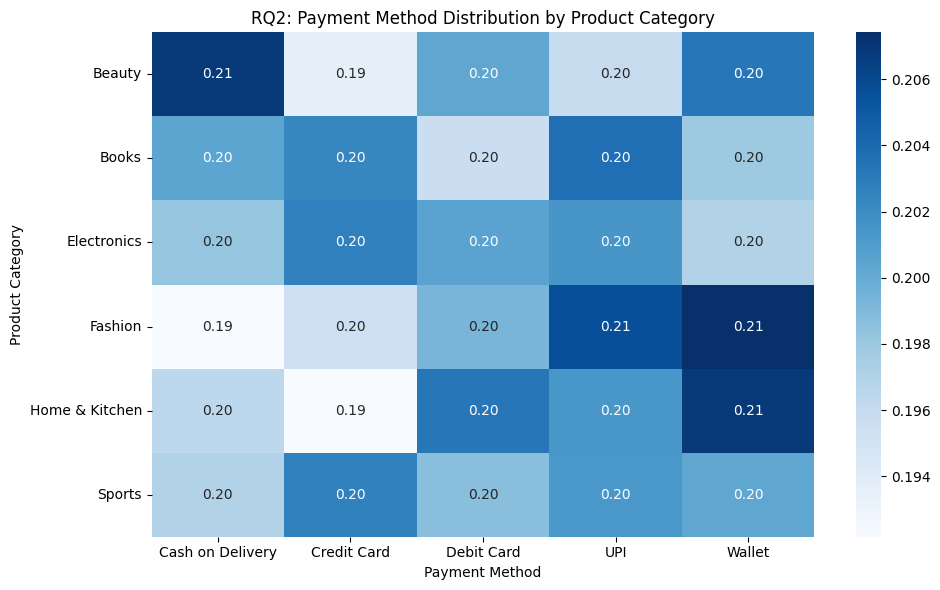

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

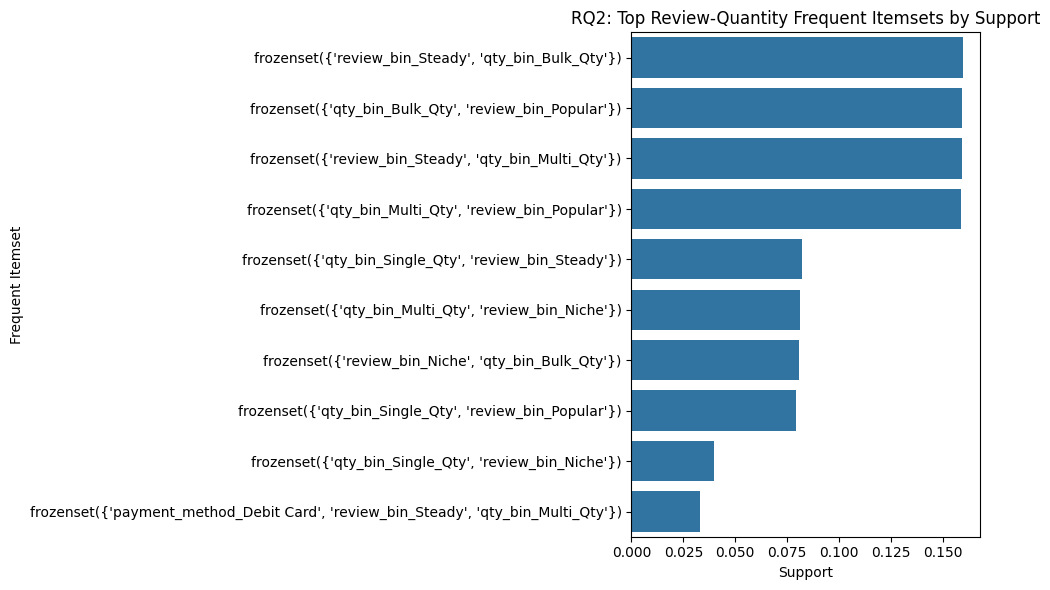

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

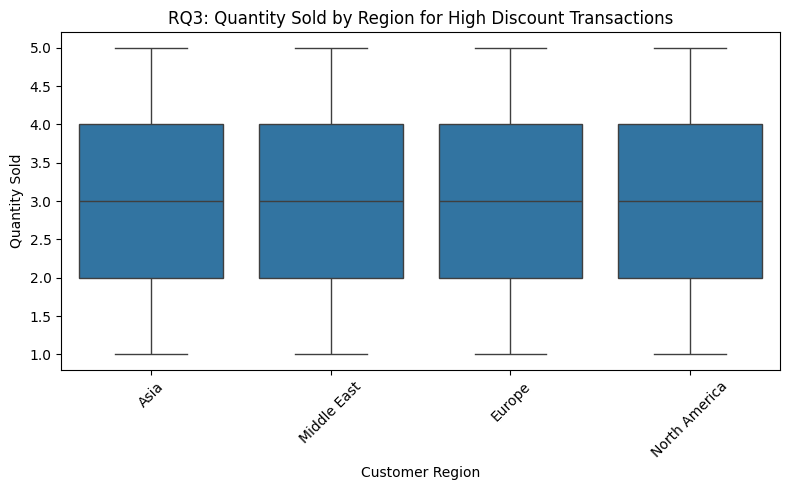

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# =================================================================
# VISUALIZATION SECTION
# =================================================================
# =================================================================
# RQ1 Visualization: Top Association Rules by Lift
# =================================================================
import warnings
import logging

# Hide Python warnings
warnings.filterwarnings("ignore")

# Suppress Jupyter client warnings specifically
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import seaborn as sns

if not rules_rq1.empty:
    top_rq1_plot = rules_rq1.sort_values(by='lift', ascending=False).head(10).copy()

    top_rq1_plot['rule'] = (
        top_rq1_plot['antecedents'].astype(str)
        + " → "
        + top_rq1_plot['consequents'].astype(str)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_rq1_plot, y='rule', x='lift')
    plt.title('RQ1: Top Association Rules by Lift')
    plt.xlabel('Lift')
    plt.ylabel('Association Rule')
    plt.tight_layout()
    plt.show()
else:
    print("No RQ1 rules available for plotting.")



# =================================================================
# RQ2 Visualization 1: Bulk Quantity Probability Given Popular Reviews
# =================================================================

if 'rq2_review_sales_summary' in globals():
    rq2_plot = rq2_review_sales_summary.sort_values(
        by='P(Bulk_Qty | Popular Reviews)',
        ascending=False
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=rq2_plot,
        x='product_category',
        y='P(Bulk_Qty | Popular Reviews)'
    )
    plt.title('RQ2: Probability of Bulk Quantity Given Popular Reviews')
    plt.xlabel('Product Category')
    plt.ylabel('P(Bulk Quantity | Popular Reviews)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("RQ2 review-sales summary not found.")

# =================================================================
# RQ2 Visualization 2: Payment Method Distribution by Category
# =================================================================

if 'payment_category_table' in globals():
    plt.figure(figsize=(10, 6))
    sns.heatmap(payment_category_table, annot=True, fmt=".2f", cmap="Blues")
    plt.title('RQ2: Payment Method Distribution by Product Category')
    plt.xlabel('Payment Method')
    plt.ylabel('Product Category')
    plt.tight_layout()
    plt.show()
else:
    print("Payment category table not found.")

# =================================================================
# RQ2 Visualization 3: Top Frequent Itemsets by Support
# =================================================================

if 'review_qty_itemsets' in globals() and not review_qty_itemsets.empty:
    top_itemsets = review_qty_itemsets.head(10).copy()
    top_itemsets['itemset'] = top_itemsets['itemsets'].astype(str)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_itemsets, y='itemset', x='support')
    plt.title('RQ2: Top Review-Quantity Frequent Itemsets by Support')
    plt.xlabel('Support')
    plt.ylabel('Frequent Itemset')
    plt.tight_layout()
    plt.show()
else:
    print("No review-quantity itemsets available for plotting.")




# =================================================================
# RQ3 Visualization: Quantity Sold by Region for High Discounts
# =================================================================

high_disc_df = df[df['disc_bin'] == 'High_Disc']

plt.figure(figsize=(8, 5))
sns.boxplot(data=high_disc_df, x='customer_region', y='quantity_sold')
plt.title('RQ3: Quantity Sold by Region for High Discount Transactions')
plt.xlabel('Customer Region')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# 3. Motivation and Feasibility

### 3.1 Motivation

Understanding customer purchasing behavior is a central problem in e-commerce. Businesses often rely on intuitive signals such as discounts, ratings, and review counts to influence customer decisions. However, it is not always clear whether these signals truly drive purchasing behavior or whether their impact is limited.

This project is motivated by the need to **empirically evaluate these common assumptions**. Specifically, it investigates whether:
- higher discounts and ratings are associated with higher quantity sold,
- higher review counts influence purchasing behavior,
- payment methods vary across product categories,
- and whether customers in different regions respond differently to discounts.

These questions are important because they relate directly to pricing strategies, product presentation, and customer experience design in online marketplaces.

---

### 3.2 Non-Triviality

The problem is non-trivial because relationships between variables such as discount, rating, review count, and quantity sold are not necessarily linear or directly observable.

For example:
- A high discount does not always lead to higher sales if customers perceive the product as low quality.
- A high rating may not increase sales if the number of reviews is low.
- Review count and quantity sold may co-occur frequently without a strong causal relationship.
- Payment preferences may appear similar across categories even if underlying customer motivations differ.

Additionally, different methods capture different aspects of the data:
- Association Rule Mining identifies co-occurrence patterns,
- Cross-tabulation and chi-square testing measure statistical dependence,
- ANOVA evaluates differences across groups.

Because each method captures a different type of relationship, combining them is necessary to obtain a more complete understanding of customer behavior.

---

### 3.3 Feasibility

The project is feasible because the dataset provides sufficient size and structure for applying the selected methods.

- The dataset contains **50,000 transactions**, which is large enough for reliable pattern discovery and statistical testing.
- Key variables such as discount percentage, rating, review count, and quantity sold can be discretized into categorical tiers, making them suitable for association rule mining and frequent itemset mining.
- Product category, payment method, and customer region are already categorical variables, allowing for direct application of cross-tabulation and statistical tests.
- The selected methods (Apriori, chi-square test, and ANOVA) are well-established and can be implemented using standard Python libraries.

Overall, the dataset and tools are well aligned with the research questions, making the analysis both practical and implementable.

---

### 3.4 Risks and Limitations

Despite its feasibility, the project has several limitations.

- **Balanced dataset structure:** Many variables are evenly distributed, which may reduce the ability to detect strong relationships.
- **Loss of information due to binning:** Discretizing continuous variables (e.g., discount and rating) simplifies analysis but may hide finer-grained patterns.
- **Association vs causation:** Methods such as association rules and frequent itemset mining identify co-occurrence, not causal relationships.
- **Limited feature space:** The dataset does not include important variables such as product price, brand, return policy, or customer history, which may play a significant role in purchasing decisions.
- **Parameter sensitivity:** Results from Apriori depend on support thresholds, and statistical tests depend on assumptions such as variance homogeneity.

These limitations mean that results should be interpreted cautiously, and conclusions should be framed in terms of observed patterns rather than definitive causal relationships.

# 4. Methodological Planning

### 4.1 Course-Based Data Mining Methods

This project uses **Apriori-based Association Rule Mining** as the main course-related data mining method.

For **RQ1**, Apriori is used to identify association rules between:

- discount tiers
- rating tiers
- quantity-sold tiers

The analysis is performed **within each product category** so that category-specific purchasing patterns can be compared. This allows the project to examine whether higher discounts or higher ratings are associated with higher quantity sold in different product groups.

For **RQ2**, Frequent Itemset Mining is also used as a supporting exploratory method. It helps identify common co-occurrence patterns involving:

- review-count tiers
- quantity-sold tiers
- product category
- payment method

However, Frequent Itemset Mining is used mainly for exploration, not as the only evidence for answering RQ2, because frequent co-occurrence does not necessarily imply a strong relationship.

---

### 4.2 Statistical and External Methods

In addition to course-based pattern mining, this project uses statistical methods to evaluate relationships more directly.

For **RQ2**, cross-tabulation is used to examine the relationship between review-count tiers and quantity-sold tiers across product categories. This allows the analysis to estimate probabilities such as:

- probability of bulk purchases given popular reviews

A **chi-square test of independence** is also used to test whether payment method varies significantly by product category. This is appropriate because both variables are categorical.

For **RQ3**, a **one-way ANOVA** test is used to determine whether customers in different regions respond differently to discount tiers in terms of quantity sold. Levene’s test is used to check the homogeneity of variance assumption before interpreting the ANOVA result. Tukey’s HSD is included as a conditional post-hoc test, but it is only applied if the ANOVA result is statistically significant.

---

### 4.3 Evaluation Strategy

Each method is evaluated using criteria appropriate to the type of analysis.

For **association rules**, the main metrics are:

- **Support:** how frequently a pattern appears
- **Confidence:** how often the consequent occurs when the antecedent occurs
- **Lift:** how much stronger the relationship is compared with random chance

Lift is especially important because it indicates whether a rule shows a meaningful association or whether the variables are nearly independent.

For **Frequent Itemset Mining**, the evaluation focuses on:

- support values
- itemset size
- whether itemsets include meaningful combinations of variables
- whether patterns show diversity across review, quantity, category, and payment-method variables

For **cross-tabulation**, the evaluation focuses on conditional distributions, especially whether the probability of higher quantity sold changes noticeably across review-count tiers or product categories.

For **chi-square testing and ANOVA**, the evaluation is based on statistical significance using p-values. A p-value below 0.05 would indicate evidence of a statistically significant relationship or group difference, while a larger p-value suggests that the observed differences are not statistically significant.

---

### 4.4 Baselines and Comparison Logic

The project uses simple baseline comparisons to avoid over-interpreting weak patterns.

For **RQ1**, the baseline is a lift value close to 1. If lift is near 1, the association rule does not show a meaningful relationship beyond random co-occurrence. Therefore, rules with lift only slightly above 1 are interpreted cautiously.

For **RQ2**, the baseline is the overall balance of review-count and quantity-sold distributions. If the probability of bulk quantity given popular reviews is similar across categories, then review count should not be interpreted as a strong category-specific driver of sales.

For the payment-method analysis, the baseline is an approximately uniform distribution of payment methods across product categories. If payment methods appear evenly distributed and the chi-square test is not significant, then there is no strong evidence that payment preference depends on product category.

For **RQ3**, the baseline is equal regional response to discount tiers. ANOVA is used to test whether regional differences are large enough to be statistically meaningful. If the p-value is high, then the analysis does not provide evidence that customers in different regions respond differently to discounts.

---

### 4.5 Expected Interpretation Framework

The interpretation framework for this project is intentionally cautious.

The project does not assume that frequent patterns automatically represent strong customer behavior. Instead, it separates:

- frequent co-occurrence
- statistical dependence
- practical business significance

This distinction is important because a pattern can appear frequently simply because the dataset is balanced or because certain values are common. Therefore, the analysis focuses not only on whether patterns exist, but also on whether they are strong enough to support meaningful conclusions.

The final interpretation will consider whether the results support or challenge common business assumptions about online purchasing behavior, such as:

- higher discounts leading to higher sales
- higher ratings increasing quantity sold
- higher review counts acting as social proof
- payment methods depending on product category
- regions responding differently to discounts

This methodological plan ensures that each research question is answered using an appropriate combination of data mining, statistical analysis, and careful interpretation.

# 5. Analysis, Findings, and Conclusion

## 5.1 Overview of Analytical Approach

This project investigated customer purchasing behavior in the Amazon Sales dataset using three connected research questions. The goal was to understand whether common business signals, such as discount level, rating, review count, payment method, and region, are meaningfully associated with sales behavior.

The analysis used a combination of data mining and statistical methods:

* **RQ1:** Apriori-based Association Rule Mining was used to evaluate whether higher discount tiers and higher rating tiers are associated with higher quantity sold within each product category.
* **RQ2:** Cross-tabulation, chi-square testing, and Frequent Itemset Mining were used to examine whether review count is associated with quantity sold and whether payment methods vary by product category.
* **RQ3:** One-way ANOVA was used to test whether customers in different regions respond differently to discount tiers in terms of quantity sold.

Before applying these methods, the dataset was checked for missing values, duplicates, and invalid ratings. The dataset was found to be clean, with no missing values, no duplicate rows, and no invalid rating values. Continuous or numerical variables such as discount percent, rating, review count, and quantity sold were discretized into categorical bins so that pattern-mining methods could be applied more effectively.

---

## 5.2 RQ1: Discount Tiers, Rating Tiers, and Quantity Sold

### Research Question

**Within each product category, are higher discount tiers and higher rating tiers associated with higher quantity sold?**

### Method

For RQ1, I used **Association Rule Mining** with the **Apriori algorithm**. The purpose was to identify whether combinations of discount tier and rating tier were associated with different levels of quantity sold within each product category.

The analysis was performed separately for each product category. This was important because customer behavior may differ depending on the type of product. For example, customers may respond differently to discounts for Electronics compared with Books, Beauty, or Fashion products.

The association rules were evaluated using:

* **Support:** how frequently a rule appears in the dataset
* **Confidence:** how often the consequent occurs when the antecedent occurs
* **Lift:** how much stronger the relationship is compared with random chance

Lift was the most important metric for interpretation. A lift value close to 1 means that the variables are nearly independent, while a lift greater than 1 indicates a positive association.

### Findings

The Apriori results showed that association rules were found across all product categories, but most of the lift values were only slightly above 1. This means that the discovered relationships were weak.

The strongest rules by category were approximately:

* **Beauty:** highest lift around **1.070**
* **Books:** highest lift around **1.063**
* **Electronics:** highest lift around **1.055**
* **Home & Kitchen:** highest lift around **1.046**
* **Sports:** highest lift around **1.045**
* **Fashion:** highest lift around **1.028**

Among all categories, **Beauty** and **Books** showed the strongest associations, but even these lift values were still close to 1. This means that the associations were present but not strong.

One notable result was in the **Electronics** category, where:

* `{High Discount} → {Bulk Quantity}` had a lift of about **1.055**

This suggests a slight positive association between high discounts and bulk purchases in Electronics. However, because the lift is only slightly above 1, the relationship is weak and should not be interpreted as strong evidence that high discounts directly drive higher sales.

In **Books**, some rules connected high rating, mid discount, and bulk quantity. For example, rules involving `{High Rating, Mid Discount}` and `{Bulk Quantity}` had lift values around **1.06**. This suggests that higher ratings may have a small relationship with higher sales in Books, but again, the strength of the association is limited.

In **Fashion**, the top lift values were only around **1.02–1.03**, suggesting almost no meaningful relationship between discount tier, rating tier, and quantity sold in that category.

### Interpretation

Overall, the RQ1 results suggest that higher discounts and higher ratings are **not strongly associated** with higher quantity sold across product categories.

Although some positive rules were identified, the lift values were consistently close to 1. This means that discount tier, rating tier, and quantity sold behave almost independently in this dataset.

This finding is important because it challenges a common business assumption. It is easy to assume that higher discounts or higher ratings automatically lead to more sales, but the data does not strongly support that assumption. In this dataset, sales behavior appears to be more complex and cannot be explained by discount and rating alone.

---


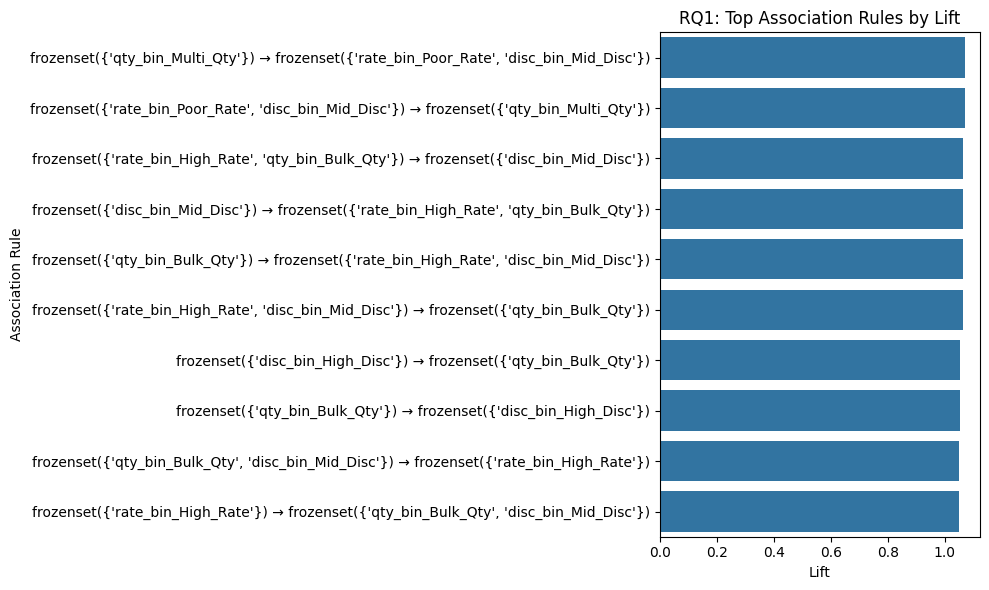

In [ ]:
# =================================================================
# RQ1 Visualization: Top Association Rules by Lift
# =================================================================
import warnings
import logging

# Hide Python warnings
warnings.filterwarnings("ignore")

# Suppress Jupyter client warnings specifically
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

if not rules_rq1.empty:
    top_rules_plot = rules_rq1.sort_values(by='lift', ascending=False).head(10).copy()

    top_rules_plot['rule'] = (
        top_rules_plot['antecedents'].astype(str)
        + " → "
        + top_rules_plot['consequents'].astype(str)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_rules_plot, y='rule', x='lift')

    plt.title('RQ1: Top Association Rules by Lift')
    plt.xlabel('Lift')
    plt.ylabel('Association Rule')

    plt.tight_layout()
    plt.show()
else:
    print("No rules available for visualization.")

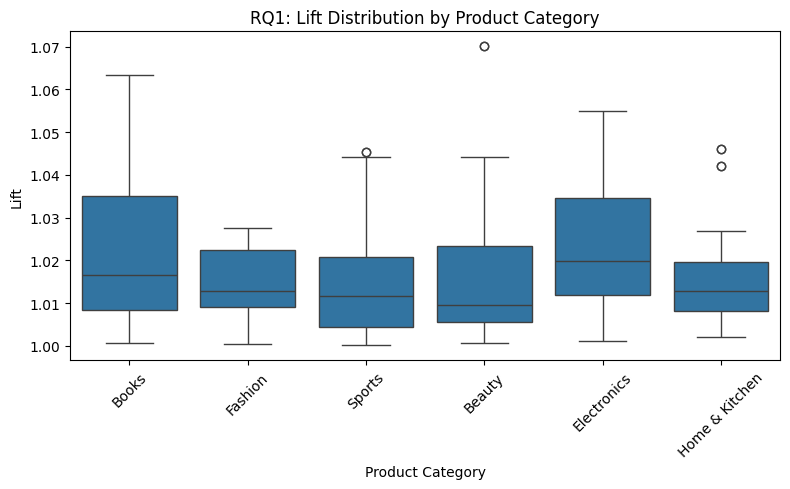

In [ ]:
# =================================================================
# RQ1 Visualization 2: Lift Distribution by Category
# =================================================================

if not rules_rq1.empty:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=rules_rq1, x='product_category', y='lift')

    plt.title('RQ1: Lift Distribution by Product Category')
    plt.xlabel('Product Category')
    plt.ylabel('Lift')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No rules available for plotting.")

---

## 5.3 RQ2: Review Count, Quantity Sold, and Payment Method

### Research Question

**Across product categories, are higher review counts associated with higher sales (quantity sold), and do payment methods vary by product category?**

### Method

RQ2 had two related parts.

The first part examined whether higher review counts are associated with higher quantity sold. This was motivated by the idea of **social proof**. In real online shopping behavior, customers may rely more on reviews for certain product categories, especially when products are harder to return, more expensive, or require more trust before purchase.

To analyze this, I used normalized cross-tabulation between:

* `review_bin`
* `qty_bin`

This allowed me to calculate the probability of bulk purchases given each review-count tier.

The second part examined whether payment methods vary by product category. This was motivated by the idea that customers may prefer certain payment methods for certain product types. For example, if customers want to inspect a product before fully committing, they may prefer payment options such as Cash on Delivery.

For this part, I used:

* Cross-tabulation between `product_category` and `payment_method`
* Chi-square test of independence
* Frequent Itemset Mining as supporting exploratory analysis

Frequent Itemset Mining was used to identify common co-occurrence patterns involving review count, quantity sold, product category, and payment method. However, the main relationship testing was done using cross-tabulation and chi-square testing.

---

### Part 1 Findings: Review Count vs Quantity Sold

The cross-tabulation results showed that the probability of bulk purchases given high review count was relatively similar across product categories.

The probability of **Bulk Quantity given Popular Reviews** was:

| Product Category | P(Bulk Quantity \| Popular Reviews) |
|---|---:|
| Fashion | 0.418 |
| Beauty | 0.406 |
| Books | 0.398 |
| Home & Kitchen | 0.395 |
| Sports | 0.394 |
| Electronics | 0.392 |

Fashion had the highest probability of bulk quantity given popular reviews, at about **41.8%**. Beauty followed with about **40.6%**. However, the differences across categories were small. Electronics had the lowest value, about **39.2%**, but this is still close to the other categories.

This suggests that products with higher review counts are not dramatically more likely to have higher quantity sold. The relationship exists only weakly, and the probabilities are relatively balanced across categories.

### Frequent Itemset Mining Findings

The Frequent Itemset Mining results also supported this conclusion. The most frequent review-quantity itemsets were:

* `{Steady Reviews, Bulk Quantity}` with support around **0.160**
* `{Popular Reviews, Bulk Quantity}` with support around **0.159**
* `{Steady Reviews, Multi Quantity}` with support around **0.159**
* `{Popular Reviews, Multi Quantity}` with support around **0.159**

These itemsets show that review count and quantity sold do appear together frequently. However, the supports are very similar across review and quantity combinations. This means that the itemsets are frequent partly because the dataset itself is balanced, not necessarily because there is a strong behavioral dependency.

In other words, high review count appears with bulk purchases, but not much more strongly than other review-count levels appear with bulk or multi-unit purchases.

### Interpretation

The results suggest that higher review count is **not a strong driver** of higher sales in this dataset.

This is an important finding because the original expectation was that customers might rely heavily on reviews before purchasing certain product categories. However, the data suggests that high review count alone does not strongly explain bulk purchasing behavior.

A possible interpretation is that review count may influence customer trust, but it is not enough by itself to explain sales volume. Other factors not included in this dataset, such as product brand, product images, delivery time, return policy, seller reputation, or product necessity, may play a larger role.

---

### Part 2 Findings: Payment Method vs Product Category

The payment-method distribution by product category was also highly balanced. For example, the share of Cash on Delivery was:

* **Beauty:** about 20.7%
* **Books:** about 20.0%
* **Electronics:** about 19.8%
* **Fashion:** about 19.2%
* **Home & Kitchen:** about 19.6%
* **Sports:** about 19.7%

Other payment methods such as Credit Card, Debit Card, UPI, and Wallet were also distributed fairly evenly across product categories.

The chi-square test result was:

* **Chi-square statistic:** 17.7508
* **Degrees of freedom:** 20
* **p-value:** 0.6038

Because the p-value is much greater than 0.05, the result does not provide evidence of a statistically significant relationship between product category and payment method.

### Interpretation

The payment-method results suggest that customers do **not** strongly choose payment methods based on product category in this dataset.

This means that the idea that customers may prefer Cash on Delivery for certain product categories is not strongly supported by the data. While there are small differences between categories, these differences are not statistically significant.

Overall, RQ2 shows that both review-driven purchasing behavior and category-specific payment preferences are weaker than expected.

---

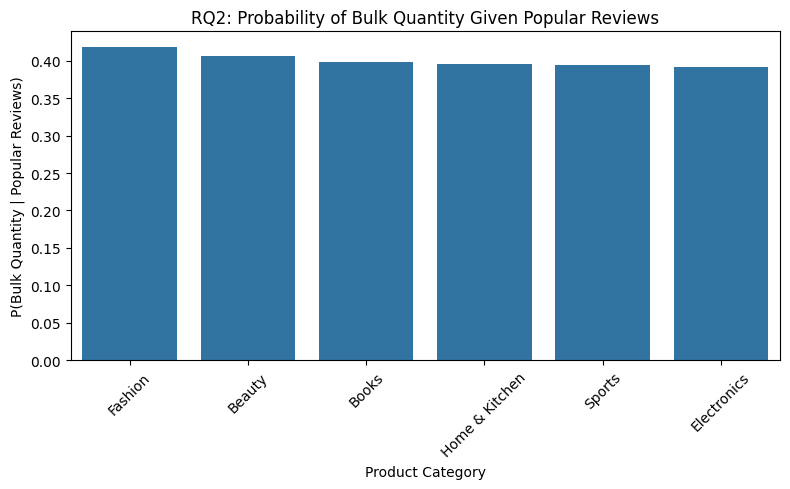

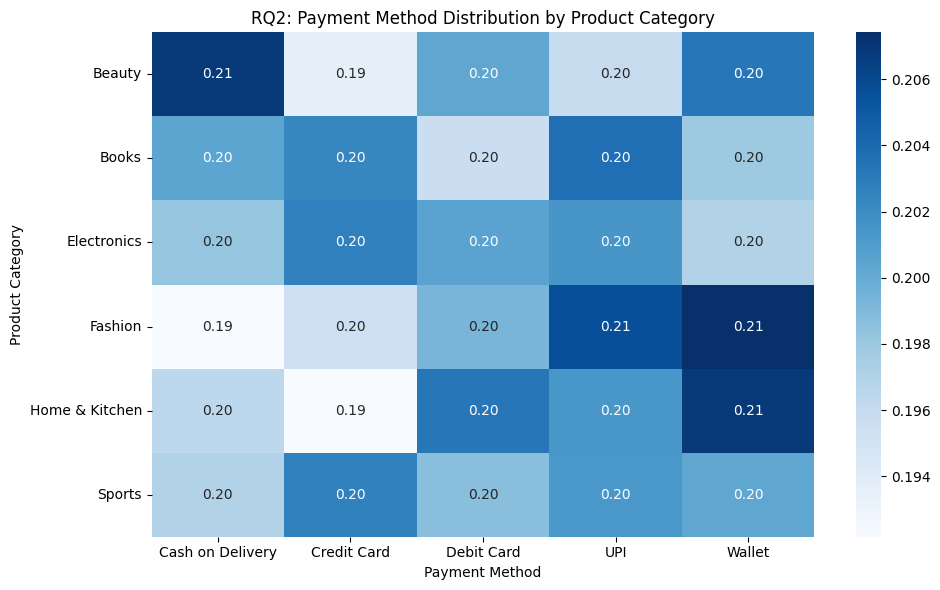

In [ ]:
# =================================================================
# RQ2 Visualization 1: Bulk Quantity Probability Given Popular Reviews
# =================================================================

rq2_plot = rq2_review_sales_summary.sort_values(
    by='P(Bulk_Qty | Popular Reviews)',
    ascending=False
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=rq2_plot,
    x='product_category',
    y='P(Bulk_Qty | Popular Reviews)'
)

plt.title('RQ2: Probability of Bulk Quantity Given Popular Reviews')
plt.xlabel('Product Category')
plt.ylabel('P(Bulk Quantity | Popular Reviews)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =================================================================
# RQ2 Visualization 2: Payment Method vs Product Category
# =================================================================

plt.figure(figsize=(10,6))
sns.heatmap(payment_category_table, annot=True, fmt=".2f", cmap="Blues")

plt.title('RQ2: Payment Method Distribution by Product Category')
plt.xlabel('Payment Method')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

---

## 5.4 RQ3: Regional Response to Discount Tiers

### Research Question

**Is there a statistically significant difference in how customers in different regions respond to discount tiers in terms of quantity sold?**

### Method

For RQ3, I used a **one-way ANOVA** test. The purpose was to determine whether customers from different regions showed significantly different quantity-sold behavior under discount conditions.

Before interpreting the ANOVA result, Levene’s test was used to check the homogeneity of variance assumption. The Levene’s test p-value was:

* **Levene’s p-value:** 0.5593

Since this value is greater than 0.05, the variance across groups can be treated as sufficiently homogeneous. This supports the validity of the ANOVA test.

### Findings

The ANOVA result was:

* **F-statistic:** 0.1532
* **p-value:** 0.9277

Since the p-value is much greater than 0.05, the result shows no statistically significant difference in quantity sold across regions under the discount condition tested.

### Interpretation

The RQ3 result suggests that customers in different regions respond similarly to discount tiers in terms of quantity sold.

This means the dataset does not provide evidence that one region is more discount-sensitive than another. From a business perspective, this suggests that region-specific discount strategies may not be necessary based on this dataset alone.

However, this should be interpreted cautiously. A non-significant ANOVA result does not prove that all regions behave exactly the same. It only means that this analysis did not find statistically significant evidence of regional differences.

---


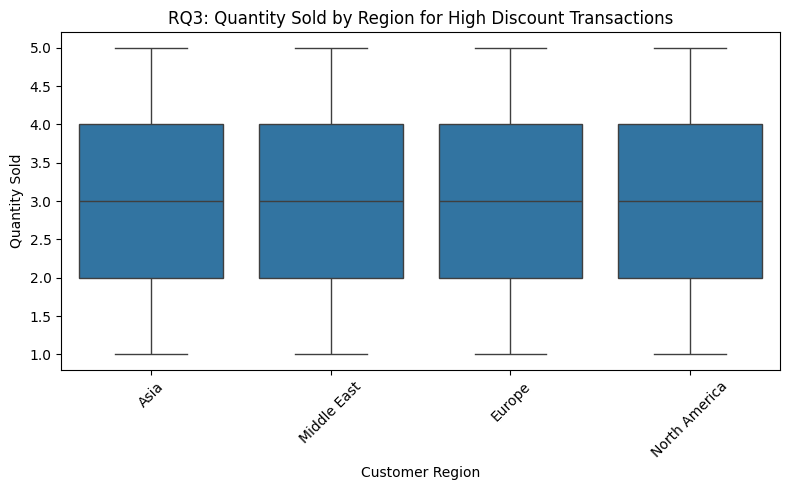

In [ ]:
# =================================================================
# RQ3 Visualization: Quantity Sold by Region (High Discount)
# =================================================================

# Filter for high discount transactions
high_disc_df = df[df['disc_bin'] == 'High_Disc']

plt.figure(figsize=(8,5))
sns.boxplot(
    data=high_disc_df,
    x='customer_region',
    y='quantity_sold'
)

plt.title('RQ3: Quantity Sold by Region for High Discount Transactions')
plt.xlabel('Customer Region')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 5.5 Validation and Quality Checks

Several validation checks were performed to evaluate the quality and reliability of the analysis.

First, the association-rule results included **94 rules with lift greater than 1.02**. This shows that some non-trivial patterns were found. However, because most lift values were still close to 1, these patterns should be interpreted as weak associations rather than strong behavioral rules.

Second, the Frequent Itemset Mining process discovered **149 multi-variable itemsets**. This indicates that the dataset contains enough categorical structure for pattern mining. However, many of these patterns have similar support values, which again reflects the balanced nature of the dataset.

Third, Levene’s test produced a p-value of **0.5593**, supporting the homogeneity of variance assumption for ANOVA.

Finally, the full dataset of **50,000 records** was successfully processed, and no missing values, duplicate rows, or invalid ratings were found.

Together, these checks show that the analysis was technically valid, but the strength of the discovered relationships was generally limited.

---

## 5.6 Overall Conclusion

Across all three research questions, the main finding is that the Amazon Sales dataset is highly balanced and does not show strong behavioral separation across discount tiers, rating tiers, review-count tiers, payment methods, or regions.

For RQ1, higher discounts and higher ratings were not strongly associated with higher quantity sold. Some positive association rules were found, especially in Beauty, Books, and Electronics, but the lift values were close to 1, indicating weak relationships.

For RQ2, higher review counts were only weakly associated with higher sales. The probability of bulk purchases given popular reviews was similar across categories, ranging from about 39% to 42%. Payment methods also did not vary significantly by product category, as shown by the chi-square p-value of 0.6038.

For RQ3, regional differences in response to discounts were not statistically significant, with an ANOVA p-value of 0.9277.

The overall conclusion is that simple business signals such as discount level, rating, review count, payment method, and region do not strongly explain sales behavior in this dataset.

This does not mean these factors are irrelevant in real-world e-commerce. Instead, it suggests that this dataset may not contain enough behavioral detail to capture stronger purchasing patterns. More informative features, such as product brand, return policy, shipping time, seller reputation, product description, customer history, and product price sensitivity, may be needed to better explain customer purchasing behavior.

---

## 5.7 Business Implications

The results suggest that businesses should be cautious about relying only on simple strategies such as increasing discounts, improving ratings, or emphasizing review count.

The analysis indicates that:

* Higher discounts do not automatically lead to higher quantity sold.
* Higher ratings do not strongly guarantee stronger sales.
* Higher review counts are not a strong standalone indicator of bulk purchasing.
* Payment preferences are not strongly category-dependent.
* Regional discount responses are statistically similar.

Therefore, a more effective business strategy would likely require richer customer and product-level data. Instead of using one-size-fits-all assumptions, companies should combine pricing data, customer behavior, product features, return policy, delivery information, and seller reputation to better understand what drives purchasing decisions.

The key takeaway is that customer purchasing behavior is more complex than simple variables like discount, rating, or review count alone.

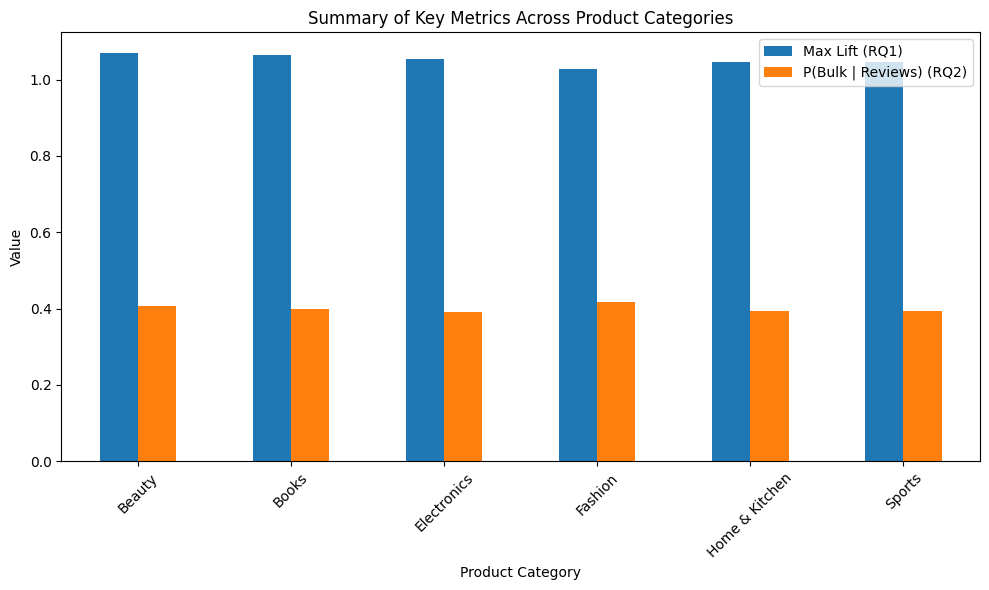

In [ ]:
# =================================================================
# Summary Visualization: Key Metrics Across Categories
# =================================================================

# RQ1: Max lift per category
rq1_summary = (
    rules_rq1.groupby('product_category')['lift']
    .max()
    .reset_index()
    .rename(columns={'lift': 'Max Lift (RQ1)'})
)

# RQ2: Already computed
rq2_summary = rq2_review_sales_summary.rename(
    columns={'P(Bulk_Qty | Popular Reviews)': 'P(Bulk | Reviews) (RQ2)'}
)

# Merge
summary_df = pd.merge(rq1_summary, rq2_summary, on='product_category')

# Plot
summary_df.set_index('product_category').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Summary of Key Metrics Across Product Categories')
plt.ylabel('Value')
plt.xlabel('Product Category')

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Collaboration Declaration

**1. Collaborators:**
* **None.** (I worked independently on this project).

**2. Web Sources:**
* **None.**

**3. AI Tools:**
* **Gemini (Google AI):** Used as a primary collaborator for structuring research questions and code generation. I utilized a series of iterative prompts to define the project scope, including asking what insights could be derived from payment methods and regional discount sensitivity while explicitly excluding anomaly detection as a viable method for this dataset. I prompted the AI to help correlate items sold per transaction to rating and review counts and to identify which regions react most strongly to high discount percentages. Further prompts requested the generation of Python code using built-in functions from `mlxtend` for association rules and `scipy/statsmodels` for ANOVA, with a specific focus on separating the analysis for each research question. Finally, I provided the raw EDA results (such as the p-value of 0.92 and Lift of 1.045) and prompted the AI to draft the Motivation, Feasibility, and Methodological Planning sections based on those specific numerical outputs to ensure the report was data-driven and met professional rubric standards.

**4. Citations:**
* **None.**